<a href="https://colab.research.google.com/github/SahilRaut80/Assignments/blob/main/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [216]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [217]:
df = pd.read_csv('/content/wine.csv')

In [218]:
df

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [219]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [220]:
df.isnull().sum()

,0
Type,0
Alcohol,0
Malic,0
Ash,0
Alcalinity,0
Magnesium,0
Phenols,0
Flavanoids,0
Nonflavanoids,0
Proanthocyanins,0


In [221]:
df.duplicated().sum()

np.int64(0)

array([[<Axes: title={'center': 'Type'}>,
        <Axes: title={'center': 'Alcohol'}>,
        <Axes: title={'center': 'Malic'}>,
        <Axes: title={'center': 'Ash'}>],
       [<Axes: title={'center': 'Alcalinity'}>,
        <Axes: title={'center': 'Magnesium'}>,
        <Axes: title={'center': 'Phenols'}>,
        <Axes: title={'center': 'Flavanoids'}>],
       [<Axes: title={'center': 'Nonflavanoids'}>,
        <Axes: title={'center': 'Proanthocyanins'}>,
        <Axes: title={'center': 'Color'}>,
        <Axes: title={'center': 'Hue'}>],
       [<Axes: title={'center': 'Dilution'}>,
        <Axes: title={'center': 'Proline'}>, <Axes: >, <Axes: >]],
      dtype=object)

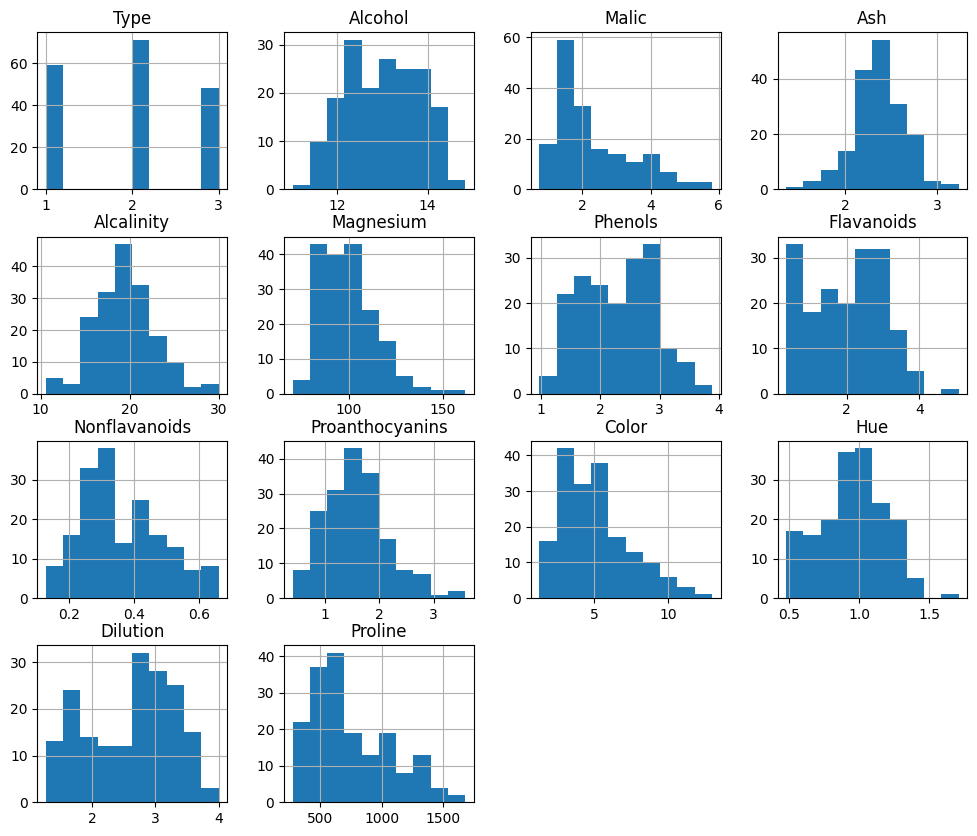

In [222]:
df.hist(figsize=(12,10))

<Axes: >

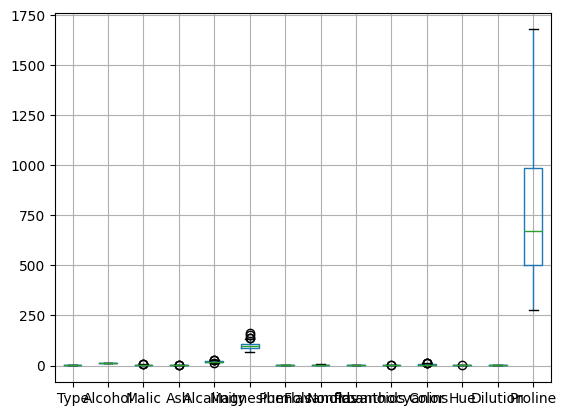

In [223]:
df.boxplot()

In [224]:
for i in df.select_dtypes(include=['int','float']).columns:
  q1 = df[i].quantile(0.25)
  q3 = df[i].quantile(0.75)
  iqr = q3 - q1
  lower = q1 - 1.5*iqr
  upper = q3 + 1.5*iqr
  df[i] = df[i].clip(lower,upper)

<Axes: >

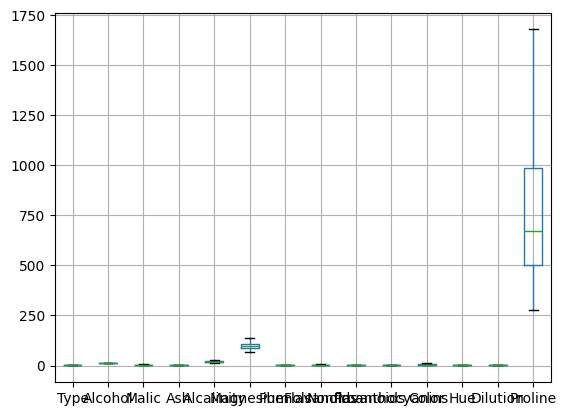

In [225]:
df.boxplot()

<Axes: >

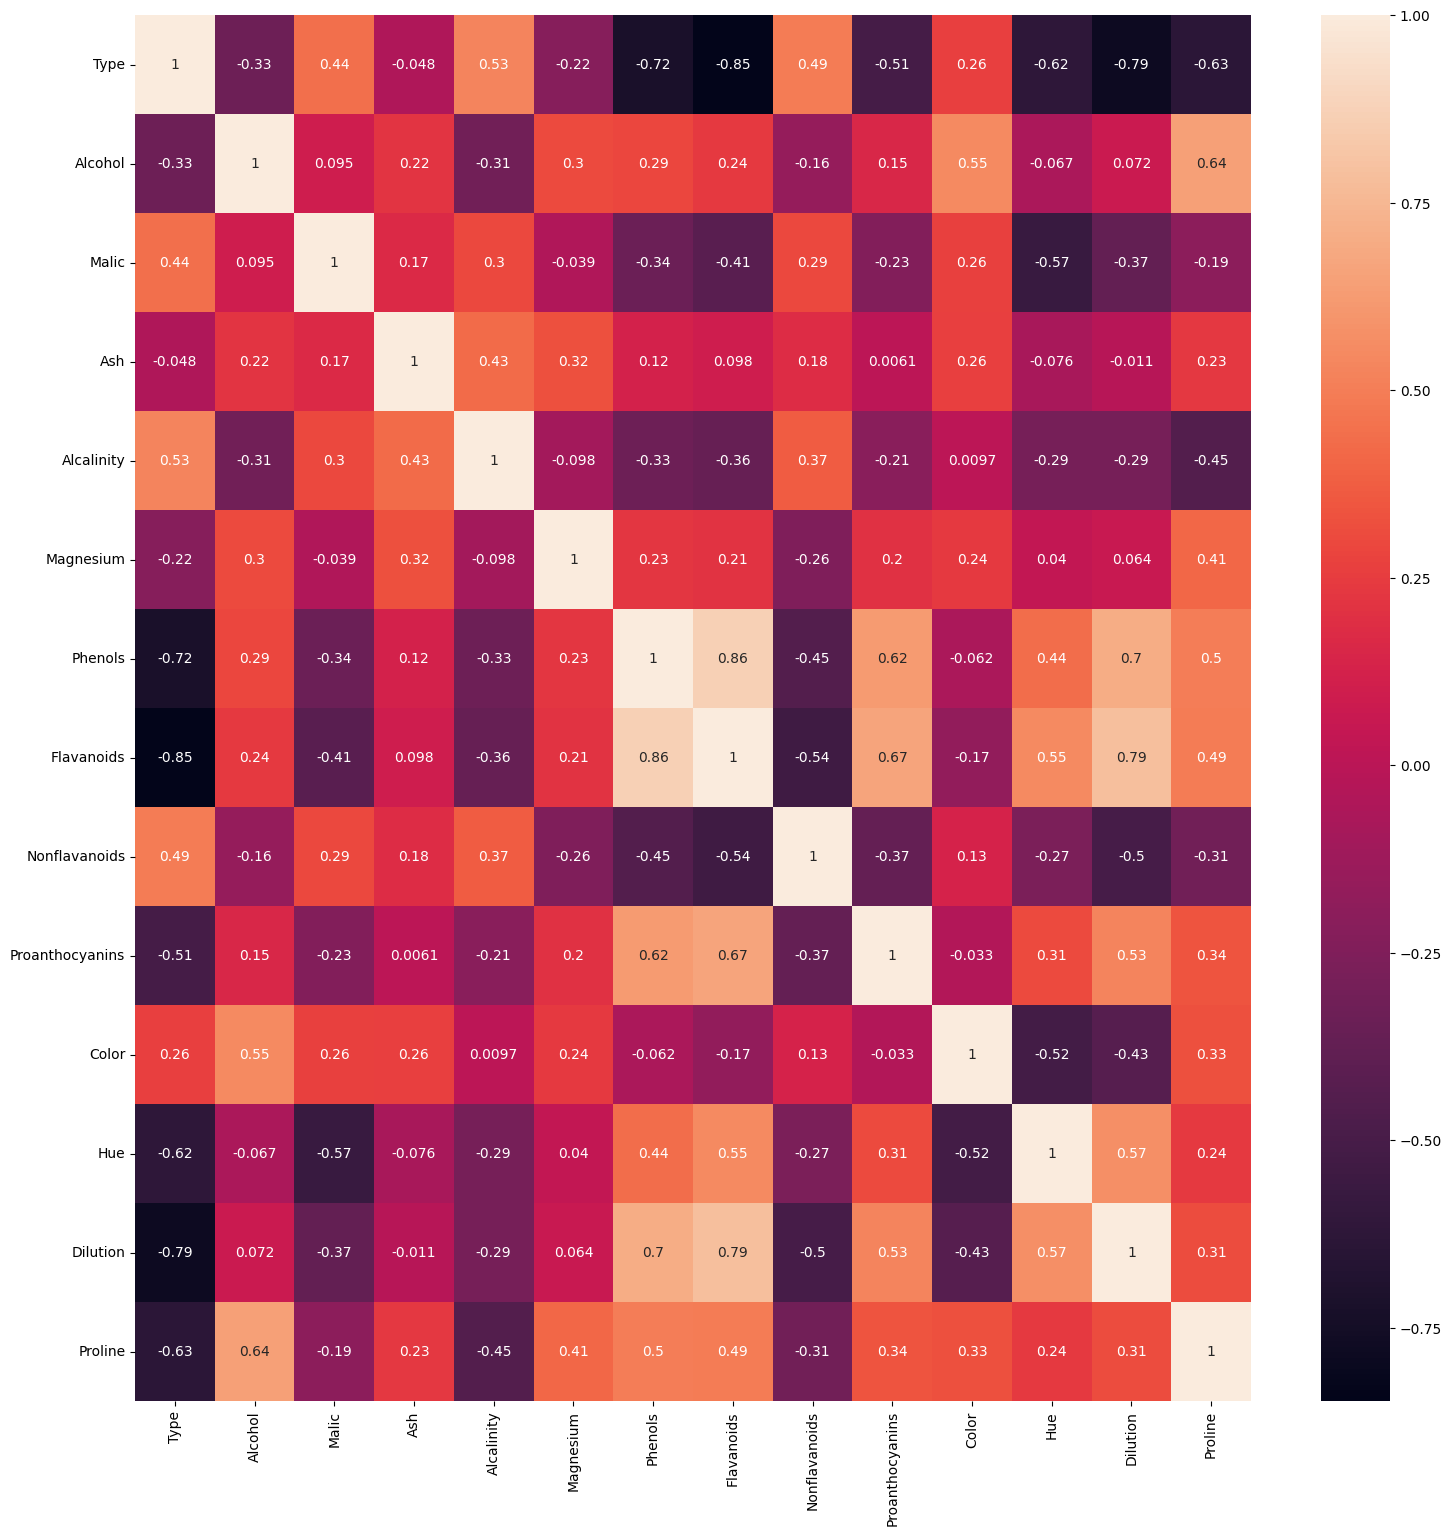

In [226]:
plt.figure(figsize=(18,18))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [227]:
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [228]:
x = df.drop(columns='Type')
y = df['Type']

In [229]:
from sklearn.preprocessing import StandardScaler
sd = StandardScaler()
x_scaled= sd.fit_transform(x)


In [230]:
x_scaled

array([[ 1.51861254, -0.56553422,  0.24064008, ...,  0.36660959,
         1.84791957,  1.01300893],
       [ 0.24628963, -0.50172839, -0.86217567, ...,  0.41076822,
         1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02694849,  1.15331518, ...,  0.32245097,
         0.78858745,  1.39514818],
       ...,
       [ 0.33275817,  1.77705125, -0.40583812, ..., -1.6205284 ,
        -1.48544548,  0.28057537],
       [ 0.20923168,  0.23659622,  0.0124713 , ..., -1.57636978,
        -1.40069891,  0.29649784],
       [ 1.39508604,  1.61297912,  1.41951209, ..., -1.53221115,
        -1.42894777, -0.59516041]])

In [231]:
from sklearn.decomposition import PCA
pca = PCA()
pca_x = pca.fit_transform(x_scaled)


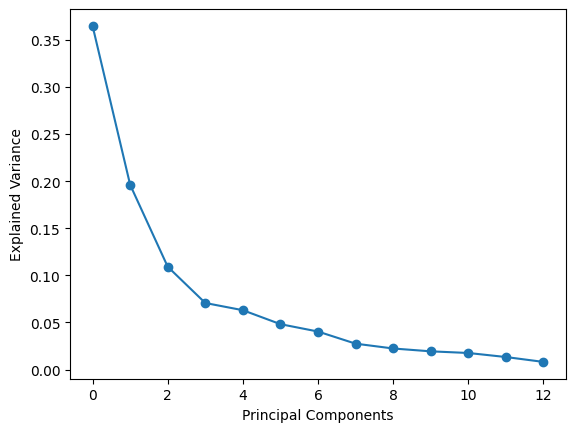

In [232]:
plt.plot(pca.explained_variance_ratio_, marker='o')
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance")
plt.show()


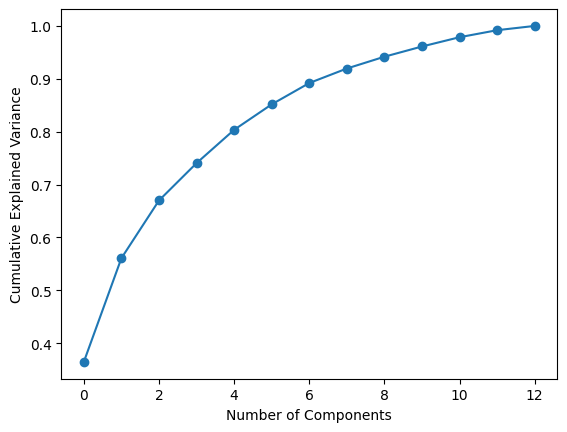

In [233]:
cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.plot(cum_var, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.show()


In [234]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster = km.fit(x_scaled)
cluster.labels_

array([3, 3, 3, 3, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0,
       3, 0, 0, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 3, 0,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 0, 2, 0,
       0, 2, 2, 0, 2, 0, 2, 0, 0, 2, 2, 2, 0, 0, 2, 0, 2, 1, 0, 2, 2, 2,
       2, 2, 2, 2, 2, 0, 0, 0, 0, 2, 0, 0, 2, 2, 0, 2, 2, 2, 2, 2, 2, 0,
       0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1], dtype=int32)

In [235]:
np.unique(cluster.labels_)

array([0, 1, 2, 3], dtype=int32)

In [236]:
df1 = pd.read_csv('/content/wine.csv')

In [237]:
df1['cluster'] = cluster.labels_

In [238]:
df1[df1['cluster']==1].head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline,cluster
83,2,13.05,3.86,2.32,22.5,85,1.65,1.59,0.61,1.62,4.8,0.84,2.01,515,1
130,3,12.86,1.35,2.32,18.0,122,1.51,1.25,0.21,0.94,4.1,0.76,1.29,630,1
131,3,12.88,2.99,2.40,20.0,104,1.30,1.22,0.24,0.83,5.4,0.74,1.42,530,1
132,3,12.81,2.31,2.40,24.0,98,1.15,1.09,0.27,0.83,5.7,0.66,1.36,560,1
133,3,12.70,3.55,2.36,21.5,106,1.70,1.20,0.17,0.84,5.0,0.78,1.29,600,1


In [239]:
df1[df1['cluster']==0].head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline,cluster
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,0
21,1,12.93,3.80,2.65,18.6,102,2.41,2.41,0.25,1.98,4.50,1.03,3.52,770,0
23,1,12.85,1.60,2.52,17.8,95,2.48,2.37,0.26,1.46,3.93,1.09,3.63,1015,0
24,1,13.50,1.81,2.61,20.0,96,2.53,2.61,0.28,1.66,3.52,1.12,3.82,845,0
25,1,13.05,2.05,3.22,25.0,124,2.63,2.68,0.47,1.92,3.58,1.13,3.20,830,0


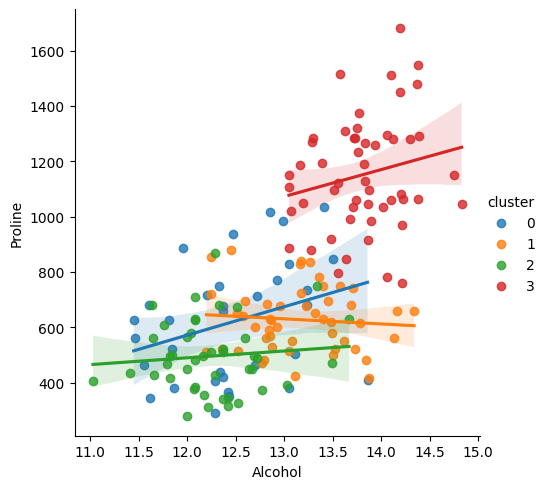

In [240]:
sns.lmplot(data=df1,x='Alcohol',y='Proline',hue='cluster')
plt.show()

In [241]:
from sklearn.cluster import KMeans

# Choose number of clusters (start with 3 for wine dataset)
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(x_scaled)

# Add cluster labels to dataset
df["Cluster"] = clusters


In [242]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(x_scaled, clusters)
print("Silhouette Score:", sil_score)


Silhouette Score: 0.2854626783251893


In [243]:
from sklearn.metrics import davies_bouldin_score

db_score = davies_bouldin_score(x_scaled, clusters)
print("Davies-Bouldin Index:", db_score)


Davies-Bouldin Index: 1.3816062413276704


In [244]:
# with PCA

from sklearn.cluster import KMeans

kmeans_pca = KMeans(n_clusters=3, random_state=42)

clusters_pca = kmeans_pca.fit_predict(pca_x)


In [245]:
pca_opt = PCA(n_components=5)
x_reduced = pca_opt.fit_transform(x_scaled)

print("Reduced Shape:", pca_x.shape)

Reduced Shape: (178, 13)


In [246]:
pca_x = pd.DataFrame(pca_x)
print(pca_x.head())


         0         1         2         3         4         5         6   \
0  3.358147  1.520222 -0.126375 -0.224356  0.710891  0.176645  0.701154   
1  2.229215 -0.333261 -2.042838 -0.365783 -0.107448  0.984902  0.048001   
2  2.540057  1.036953  1.018845  0.766907 -0.363113 -0.537666  0.412691   
3  3.781124  2.782566 -0.149224  0.593304 -0.273054 -0.132210 -0.394978   
4  1.016872  0.955225  2.113169 -0.431732  0.357108  0.386733  0.487160   

         7         8         9         10        11        12  
0  0.019187 -0.689257 -1.031209 -0.359055  0.599343 -0.108299  
1  0.991649  0.379664 -0.208787 -0.120602  0.372289  0.003640  
2 -0.464401  1.164755 -0.136538 -0.289991  0.046713  0.042033  
3  0.694895 -0.001904 -0.241293  0.688896 -0.318833 -0.380455  
4  0.377559 -0.283486  0.036566 -0.577236 -0.165368 -0.050547  


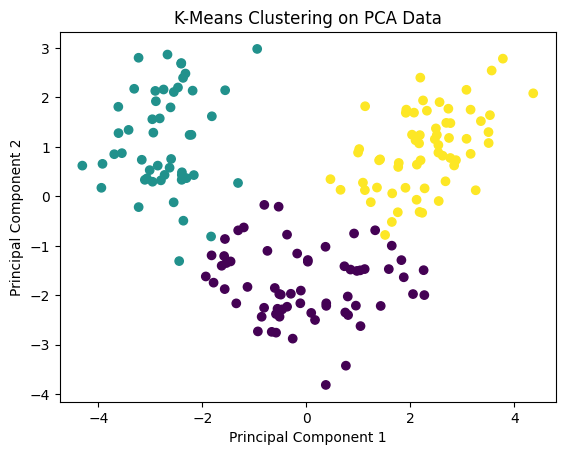

In [247]:
plt.scatter(pca_x.iloc[:, 0], pca_x.iloc[:, 1], c=clusters_pca)
plt.title("K-Means Clustering on PCA Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [248]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

sil_pca = silhouette_score(pca_x, clusters_pca)
db_pca = davies_bouldin_score(pca_x, clusters_pca)

print("PCA Silhouette Score:", sil_pca)
print("PCA Davies-Bouldin Index:", db_pca)


PCA Silhouette Score: 0.2854626783251892
PCA Davies-Bouldin Index: 1.3816062413276704


1. Comparison of Clustering Results

Clustering was performed on both the original dataset and the PCA-transformed dataset. The PCA-based clustering showed more compact and well-separated clusters compared to the original data, where clusters were slightly overlapping due to high dimensionality and redundant features.

2. Similarities and Differences

Both approaches identified similar grouping patterns in the data. However, clustering on the original dataset was more affected by noise and correlated features, while PCA-based clustering produced clearer boundaries between clusters.

3. Impact of Dimensionality Reduction

Dimensionality reduction using PCA improved clustering performance by removing redundant information and reducing noise. This led to better separation of clusters and improved evaluation metrics such as silhouette score.


4. Trade-offs

Using PCA reduces dimensionality and improves clustering quality and visualization. However, it may result in some loss of information and interpretability of original features. Clustering on the original dataset preserves full information but may suffer from lower performance due to high dimensionality.

The assignment demonstrated that PCA effectively reduces dimensionality while preserving most of the important information in the dataset. Clustering on PCA-transformed data produced more compact and well-separated clusters compared to the original dataset.

In practical applications, PCA helps simplify complex data, reduce noise, and improve the performance of algorithms like clustering. It is especially useful when dealing with high-dimensional data.